In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import AgglomerativeClustering

sns.set_style("whitegrid")

In [2]:
data = pd.read_csv("Train.csv")

print("Dataset Dimensions:", data.shape)

data.head()

Dataset Dimensions: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
print("Missing Value Count:\n")

print(data.isna().sum())

Missing Value Count:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [4]:
cluster_data = data[["Cost_of_the_Product","Discount_offered"]].copy()

cluster_data.head()

,Cost_of_the_Product,Discount_offered
0,177,44
1,216,59
2,183,48
3,176,10
4,184,46


In [5]:
cluster_data["Cost_sqrt"] = np.sqrt(cluster_data["Cost_of_the_Product"])
cluster_data["Discount_sqrt"] = np.sqrt(cluster_data["Discount_offered"])

cluster_data[["Cost_sqrt","Discount_sqrt"]].head()

,Cost_sqrt,Discount_sqrt
0,13.304135,6.633250
1,14.696938,7.681146
2,13.527749,6.928203
3,13.266499,3.162278
4,13.564660,6.782330


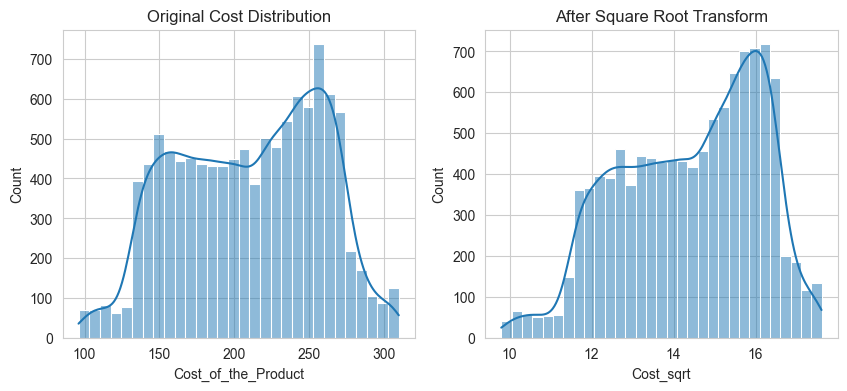

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(cluster_data["Cost_of_the_Product"], kde=True)
plt.title("Original Cost Distribution")

plt.subplot(1,2,2)
sns.histplot(cluster_data["Cost_sqrt"], kde=True)
plt.title("After Square Root Transform")

plt.show()

In [7]:
scaler = RobustScaler()

scaled_features = scaler.fit_transform(
    cluster_data[["Cost_sqrt","Discount_sqrt"]]
)

In [8]:
cluster_model = AgglomerativeClustering(n_clusters=3)

labels = cluster_model.fit_predict(scaled_features)

cluster_data["Group"] = labels

cluster_data.head()

,Cost_of_the_Product,Discount_offered,Cost_sqrt,Discount_sqrt,Group
0,177,44,13.304135,6.633250,0
1,216,59,14.696938,7.681146,0
2,183,48,13.527749,6.928203,0
3,176,10,13.266499,3.162278,2
4,184,46,13.564660,6.782330,0


In [9]:
for g in sorted(cluster_data["Group"].unique()):

    print("\nCluster Group:", g)

    print(
        cluster_data[cluster_data["Group"]==g]
        [["Cost_of_the_Product","Discount_offered"]]
        .describe()
    )


Cluster Group: 0
       Cost_of_the_Product  Discount_offered
count          2533.000000       2533.000000
mean            195.182392         39.361627
std              45.573291         15.278442
min              96.000000         11.000000
25%             157.000000         26.000000
50%             191.000000         40.000000
75%             233.000000         52.000000
max             296.000000         65.000000

Cluster Group: 1
       Cost_of_the_Product  Discount_offered
count          5158.000000       5158.000000
mean            247.341411          5.625242
std              25.457268          3.030022
min             190.000000          1.000000
25%             228.000000          3.000000
50%             248.000000          6.000000
75%             265.000000          8.000000
max             310.000000         15.000000

Cluster Group: 2
       Cost_of_the_Product  Discount_offered
count          3308.000000       3308.000000
mean            163.775998          5.554414
s

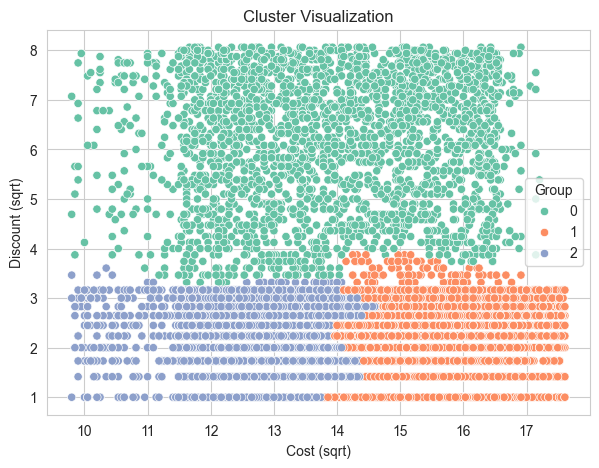

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=cluster_data["Cost_sqrt"],
    y=cluster_data["Discount_sqrt"],
    hue=cluster_data["Group"],
    palette="Set2"
)

plt.title("Cluster Visualization")
plt.xlabel("Cost (sqrt)")
plt.ylabel("Discount (sqrt)")

plt.show()

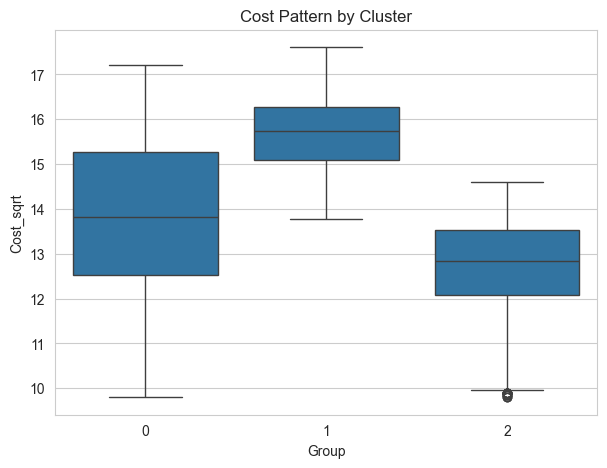

In [11]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Group",
    y="Cost_sqrt",
    data=cluster_data
)

plt.title("Cost Pattern by Cluster")

plt.show()

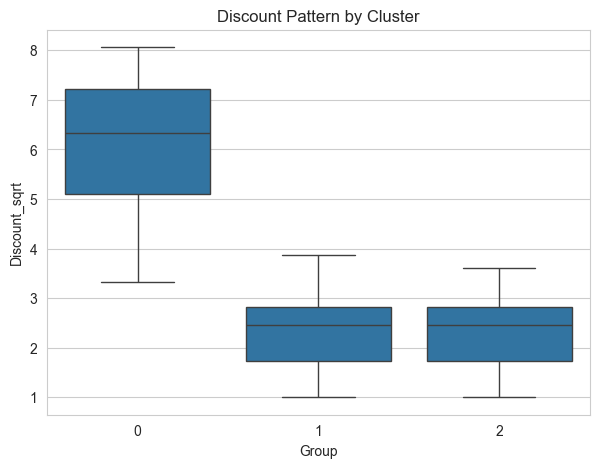

In [12]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Group",
    y="Discount_sqrt",
    data=cluster_data
)

plt.title("Discount Pattern by Cluster")

plt.show()